# 01 Data Setup And Train GAN

Use this notebook for dataset sanity checks, image previews, and a standalone GAN run in `runs/gan/`. On shared CUDA hosts, keep `DEVICE_OVERRIDE="auto"` unless you want to pin a specific GPU. If the visible GPUs stay full, you can enable `CPU_FALLBACK_WHEN_CUDA_BUSY` for a slower but more resilient run.


In [1]:
from pathlib import Path
import os
import sys
from pprint import pprint

from IPython.display import display
from PIL import Image

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

from config import Config
from workflow import sample_image_paths, summarize_dataset, train_gan

ROOT


PosixPath('/home/arderd/gan-lab-task-1')

In [2]:
# Edit these values before running.
cfg = Config().with_runtime_profile_defaults()
DATA_ROOT = ROOT / "data_final"
OUT_DIR = ROOT / "runs" / "gan"
TRAIN_N_PER_CLASS = None
STRICT_FID = True

# Shared-GPU overrides. Leave DEVICE_OVERRIDE="auto" to use the visible CUDA
# device with the most free memory. Lower CUDA_MIN_FREE_GIB_OVERRIDE only
# if you want a riskier start threshold on a crowded shared GPU.
DEVICE_OVERRIDE = "auto"  # e.g. "cuda:0" or "cuda:1"
CUDA_MIN_FREE_GIB_OVERRIDE = None  # e.g. 1.5 or 1.0
CPU_FALLBACK_WHEN_CUDA_BUSY = False
NUM_WORKERS_OVERRIDE = None

# Optional quick smoke-run overrides for notebook debugging.
SMOKE_GAN_OVERRIDES = {}
overrides = dict(SMOKE_GAN_OVERRIDES)
if DEVICE_OVERRIDE != "auto":
    overrides["device"] = DEVICE_OVERRIDE
if CUDA_MIN_FREE_GIB_OVERRIDE is not None:
    overrides["cuda_min_free_gib"] = CUDA_MIN_FREE_GIB_OVERRIDE
overrides["cpu_fallback_when_cuda_busy"] = CPU_FALLBACK_WHEN_CUDA_BUSY
if NUM_WORKERS_OVERRIDE is not None:
    overrides["num_workers"] = NUM_WORKERS_OVERRIDE
if overrides:
    cfg = cfg.with_overrides(**overrides)

{
    "cfg": cfg,
    "resolved_device": cfg.resolve_device(),
    "cuda_min_free_gib": cfg.cuda_min_free_gib,
    "cpu_fallback_when_cuda_busy": cfg.cpu_fallback_when_cuda_busy,
    "loader_options": cfg.loader_options(),
    "data_root": DATA_ROOT,
    "out_dir": OUT_DIR,
    "train_n_per_class": TRAIN_N_PER_CLASS,
    "strict_fid": STRICT_FID,
}


{'cfg': Config(data_root=PosixPath('data_final'), out_root=PosixPath('runs'), img_size=64, channels=3, seed=42, z_dim=128, gan_batch=80, gan_epochs=200, gan_lr_g=0.0002, gan_lr_d=0.0001, sample_every=25, ckpt_every=25, fid_every=25, fid_n_samples=2048, fid_enabled=True, fid_reference_split='train', clf_batch=64, clf_epochs=50, clf_lr=0.0003, num_workers=4, persistent_workers=False, prefetch_factor=2, classifier_compile=False, runtime_profile='default', device='auto', cuda_auto_select='most_free', cuda_min_free_gib=2.0, pin_memory=None, allow_tf32=True),
 'resolved_device': 'cuda:1',
 'cuda_min_free_gib': 2.0,
 'loader_options': {'num_workers': 4,
  'pin_memory': True,
  'persistent_workers': False,
  'prefetch_factor': 2},
 'data_root': PosixPath('/home/arderd/gan-lab-task-1/data_final'),
 'out_dir': PosixPath('/home/arderd/gan-lab-task-1/runs/gan'),
 'train_n_per_class': None,
 'strict_fid': True}

{'test': {'apple': 492, 'banana': 492, 'orange': 492},
 'train': {'apple': 1300, 'banana': 1300, 'orange': 1300},
 'val': {'apple': 159, 'banana': 159, 'orange': 159}}
apple Apple_10__r0_104_100.jpg


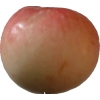

banana Banana_1__0_100.jpg


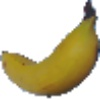

orange Clementine_1__10_100.jpg


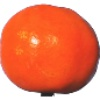

In [3]:
dataset_summary = summarize_dataset(DATA_ROOT)
pprint(dataset_summary)

for class_name, sample_path in sample_image_paths(DATA_ROOT):
    print(class_name, sample_path.name)
    display(Image.open(sample_path))


## GAN Training

This notebook keeps the standalone GAN workflow available. For the full Task 1 pipeline, use `02_generate_synthetic_data_and_classifier_experiments.ipynb`.


In [4]:
gan_run = train_gan(
    cfg,
    data_root=DATA_ROOT,
    fid_root=DATA_ROOT,
    out_dir=OUT_DIR,
    train_n_per_class=TRAIN_N_PER_CLASS,
    strict_fid=STRICT_FID,
)
gan_run["summary"]


Device: cuda:1
CUDA runtime: index=1 name=NVIDIA H100 NVL free=2.1GiB/93.1GiB
Loader options: {'num_workers': 4, 'pin_memory': True, 'persistent_workers': False, 'prefetch_factor': 2}
Train loader ready: 3900 images across 3 classes
FID loader ready: 3900 images from 'train' split
GAN initialized: batch=80, z_dim=128, fid_enabled=True, fid_n_samples=2048
Starting GAN training...
[Epoch 001/200]  D_loss: 2.1372  G_loss: 10.1712  D(x): 0.830  D(G(z)): 0.159  Time: 2.6s
[Epoch 002/200]  D_loss: 1.9111  G_loss: 6.4225  D(x): 0.752  D(G(z)): 0.207  Time: 1.7s
[Epoch 003/200]  D_loss: 1.6722  G_loss: 3.7420  D(x): 0.702  D(G(z)): 0.252  Time: 1.6s
[Epoch 004/200]  D_loss: 1.5006  G_loss: 2.6109  D(x): 0.664  D(G(z)): 0.293  Time: 1.6s
[Epoch 005/200]  D_loss: 1.2850  G_loss: 2.2832  D(x): 0.674  D(G(z)): 0.292  Time: 1.6s
[Epoch 006/200]  D_loss: 1.4835  G_loss: 2.1020  D(x): 0.664  D(G(z)): 0.329  Time: 1.7s
[Epoch 007/200]  D_loss: 1.7144  G_loss: 2.2446  D(x): 0.639  D(G(z)): 0.329  Time:

{'data_root': '/home/arderd/gan-lab-task-1/data_final',
 'fid_root': '/home/arderd/gan-lab-task-1/data_final',
 'fid_reference_split': 'train',
 'device': 'cuda:1',
 'loader_options': {'num_workers': 4,
  'pin_memory': True,
  'persistent_workers': False,
  'prefetch_factor': 2},
 'runtime_summary': {'device': 'cuda:1',
  'loader_options': {'num_workers': 4,
   'pin_memory': True,
   'persistent_workers': False,
   'prefetch_factor': 2},
  'allow_tf32': True,
  'visible_cuda_devices': [{'cuda_index': 0,
    'cuda_name': 'NVIDIA H100 NVL',
    'cuda_free_gib': 0.4,
    'cuda_total_gib': 93.1},
   {'cuda_index': 1,
    'cuda_name': 'NVIDIA H100 NVL',
    'cuda_free_gib': 2.1,
    'cuda_total_gib': 93.1}],
  'cuda_device_count': 2,
  'cuda_index': 1,
  'cuda_name': 'NVIDIA H100 NVL',
  'cuda_free_gib': 2.1,
  'cuda_total_gib': 93.1},
 'num_classes': 3,
 'train_samples': 3900,
 'fid_samples': 3900,
 'train_n_per_class': None,
 'train_time_sec': 1095.3,
 'best_fid': 162.2329,
 'best_epoch':